# Teleco_Churn_Analysis


## TASK 1 — Data Loading & Exploratory Analysis

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [79]:
df = pd.read_csv("E:\Internship_Data_Analysis\Data_Analysis_Internship Week 2\Dataset\WA_Fn-UseC_-Telco-Customer-Churn.csv") # Load the dataset
print(df.head()) # Display the first few rows of the dataset        

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [80]:
print("Shape:", df.shape)
print("\nColumn Types:\n", df.dtypes)
print("\nFirst 10 rows:")

Shape: (7043, 21)

Column Types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

First 10 rows:


Churn value counts:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn %:
 Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


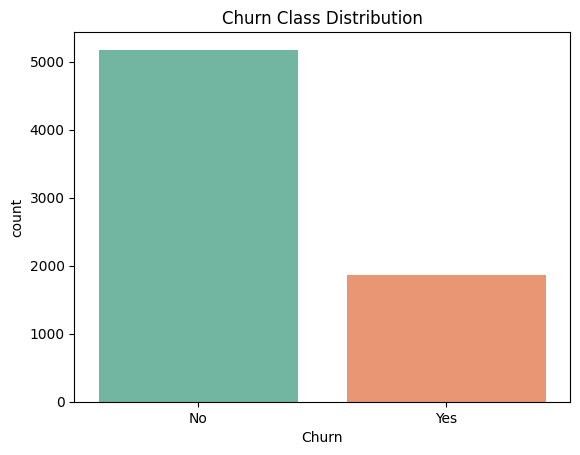

In [81]:
# ── Target column: Churn — check class imbalance ──────────────
print("Churn value counts:\n", df['Churn'].value_counts())
print("\nChurn %:\n", df['Churn'].value_counts(normalize=True) * 100)

sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Churn Class Distribution')
plt.savefig('charts/churn_distribution.png', bbox_inches='tight')
plt.show()

In [82]:
# Missing / Null Values
print("Null values per column:\n", df.isnull().sum())
# TotalCharges has hidden nulls — it's stored as object, spaces = nulls
print("\nTotalCharges unique sample:", df['TotalCharges'].unique()[:10])

Null values per column:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

TotalCharges unique sample: ['29.85' '1889.5' '108.15' '1840.75' '151.65' '820.5' '1949.4' '301.9'
 '3046.05' '3487.95']


In [83]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [84]:
# ── Summary Statistics for Numerical Columns 
print(df.describe())

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


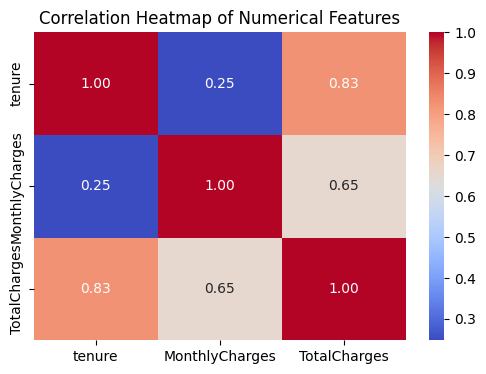

In [85]:
#Correlation Heatmap 
# Only numerical columns for now
num_df = df[['tenure', 'MonthlyCharges','TotalCharges']].copy()
num_df['TotalCharges'] = pd.to_numeric(num_df['TotalCharges'], errors='coerce')

plt.figure(figsize=(6, 4))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.savefig('charts/correlation_heatmap.png', bbox_inches='tight')
plt.show()

Why Use a Correlation Heatmap?

Identify Multicollinearity: Spot redundant features that tell the model the same thing (e.g., tenure and TotalCharges). Removing overlapping features prevents model instability.

Find Predictive Power: Quickly discover which features are most strongly correlated with your target variable so you know what drives the predictions.

Data Sanity Checks: Verify that logical relationships actually exist in your data and catch hidden parsing errors.

## TASK 2 — Data Preprocessing & Feature Engineering

In [86]:
# ── Step 1: Fix TotalCharges (object → numeric) ───────────────
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many became NaN
print("NaN in TotalCharges after coercion:", df['TotalCharges'].isnull().sum())

# Logic: If TotalCharges is missing, calculate it manually for those rows
df['TotalCharges'] = df['TotalCharges'].fillna(df['tenure'] * df['MonthlyCharges'])

NaN in TotalCharges after coercion: 11


In [87]:
# ── Step 2: Drop customerID (not useful for modeling) 
df.drop(columns=['customerID'], inplace=True)

# ── Step 3: Encode target column Churn (Yes=1, No=0) ──────────
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

Label Encoding

In [88]:
# Cell 1 — Label Encoding (binary cols)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'MultipleLines', 'OnlineSecurity',
               'OnlineBackup', 'DeviceProtection', 'TechSupport',
               'StreamingTV', 'StreamingMovies']

for col in binary_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print(df[binary_cols].head(3))

   gender  Partner  Dependents  PhoneService  PaperlessBilling  MultipleLines  \
0       0        1           0             0                 1              1   
1       1        0           0             1                 0              0   
2       1        0           0             1                 1              0   

   OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  StreamingTV  \
0               0             2                 0            0            0   
1               2             0                 2            0            0   
2               2             2                 0            0            0   

   StreamingMovies  
0                0  
1                0  
2                0  


One hot Encoding

In [89]:
# Cell 2 — One-Hot Encoding (multi-class cols)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

multi_cols = ['InternetService', 'Contract', 'PaymentMethod']

ct = ColumnTransformer(
    transformers=[("encoder", OneHotEncoder(sparse_output=False, handle_unknown='ignore'), multi_cols)],
    remainder='passthrough'
)

encoded_array = ct.fit_transform(df)
encoded_cols  = ct.get_feature_names_out()
df = pd.DataFrame(encoded_array, columns=encoded_cols)

print("Shape after encoding:", df.shape)
df.head(3)

Shape after encoding: (7043, 27)


,encoder__InternetService_DSL,encoder__InternetService_Fiber optic,encoder__InternetService_No,encoder__Contract_Month-to-month,encoder__Contract_One year,encoder__Contract_Two year,encoder__PaymentMethod_Bank transfer (automatic),encoder__PaymentMethod_Credit card (automatic),encoder__PaymentMethod_Electronic check,encoder__PaymentMethod_Mailed check,...,remainder__OnlineSecurity,remainder__OnlineBackup,remainder__DeviceProtection,remainder__TechSupport,remainder__StreamingTV,remainder__StreamingMovies,remainder__PaperlessBilling,remainder__MonthlyCharges,remainder__TotalCharges,remainder__Churn
0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,2.0,0.0,0.0,0.0,0.0,1.0,29.85,29.85,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,2.0,0.0,2.0,0.0,0.0,0.0,0.0,56.95,1889.50,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,2.0,2.0,0.0,0.0,0.0,0.0,1.0,53.85,108.15,1.0


In [91]:
print(df.columns.tolist())

['encoder__InternetService_DSL', 'encoder__InternetService_Fiber optic', 'encoder__InternetService_No', 'encoder__Contract_Month-to-month', 'encoder__Contract_One year', 'encoder__Contract_Two year', 'encoder__PaymentMethod_Bank transfer (automatic)', 'encoder__PaymentMethod_Credit card (automatic)', 'encoder__PaymentMethod_Electronic check', 'encoder__PaymentMethod_Mailed check', 'remainder__gender', 'remainder__SeniorCitizen', 'remainder__Partner', 'remainder__Dependents', 'remainder__tenure', 'remainder__PhoneService', 'remainder__MultipleLines', 'remainder__OnlineSecurity', 'remainder__OnlineBackup', 'remainder__DeviceProtection', 'remainder__TechSupport', 'remainder__StreamingTV', 'remainder__StreamingMovies', 'remainder__PaperlessBilling', 'remainder__MonthlyCharges', 'remainder__TotalCharges', 'remainder__Churn']


In [92]:
# Add this right after df = pd.DataFrame(encoded_array, columns=encoded_cols)
df.columns = [col.replace('remainder__', '').replace('encoder__', '') for col in df.columns]
print(df.columns.tolist())  # verify

['InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [93]:
# ── Step 5: Feature Engineering (at least 2 new features) ─────

# Feature 1: ChargesPerMonth = TotalCharges / tenure
# (avoid division by zero — customers with tenure=0 get MonthlyCharges instead)
df['ChargesPerMonth'] = df.apply(
    lambda row: row['TotalCharges'] / row['tenure'] if row['tenure'] > 0 else row['MonthlyCharges'],
    axis=1
)

# Feature 2: SeniorWithNoSupport
# SeniorCitizen is already 0/1, TechSupport was label-encoded
# Check what 'No' maps to in TechSupport before running this
# Since LabelEncoder is alphabetical: No=0, No internet service=1, Yes=2
df['SeniorWithNoSupport'] = ((df['SeniorCitizen'] == 1) & (df['TechSupport'] == 0)).astype(int)

print("New features added: ChargesPerMonth, SeniorWithNoSupport")
print(df[['ChargesPerMonth', 'SeniorWithNoSupport']].describe())

New features added: ChargesPerMonth, SeniorWithNoSupport
       ChargesPerMonth  SeniorWithNoSupport
count      7043.000000          7043.000000
mean         64.762906             0.117848
std          30.189796             0.322450
min          13.775000             0.000000
25%          35.935156             0.000000
50%          70.337500             0.000000
75%          90.174158             0.000000
max         121.400000             1.000000


In [94]:
# ── Step 6: Scale Numerical Features ──────────────────────────
from sklearn.preprocessing import StandardScaler

scale_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'ChargesPerMonth']
scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

In [95]:
# ── Step 7: Train/Test Split (Stratified) ─────────────────────
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Churn ratio in train:", y_train.mean().round(3))
print("Churn ratio in test:", y_test.mean().round(3))

Train size: (5634, 28)
Test size: (1409, 28)
Churn ratio in train: 0.265
Churn ratio in test: 0.265


## TASK 3 — Model Training & Comparison

In [96]:
import os
os.makedirs('charts', exist_ok=True)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, roc_curve)

#Train all 3 models and evaluate on test set 
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'model':    model,
        'y_pred':   y_pred,
        'y_proba':  y_proba,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision':precision_score(y_test, y_pred),
        'Recall':   recall_score(y_test, y_pred),
        'F1':       f1_score(y_test, y_pred),
        'ROC-AUC':  roc_auc_score(y_test, y_proba)
    }
    print(f"\n{name}: Acc={results[name]['Accuracy']:.3f} | F1={results[name]['F1']:.3f} | AUC={results[name]['ROC-AUC']:.3f}")


Logistic Regression: Acc=0.803 | F1=0.598 | AUC=0.842

Random Forest: Acc=0.787 | F1=0.551 | AUC=0.826

Gradient Boosting: Acc=0.806 | F1=0.586 | AUC=0.843


In [97]:
# ── Metrics Summary Table ──────────────────────────────────────
metrics_df = pd.DataFrame({
    name: {k: v for k, v in vals.items() if k not in ['model', 'y_pred', 'y_proba']}
    for name, vals in results.items()
}).T.round(4)

print(metrics_df)

                     Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression    0.8027     0.6509  0.5535  0.5983   0.8422
Random Forest          0.7871     0.6259  0.4920  0.5509   0.8264
Gradient Boosting      0.8055     0.6736  0.5187  0.5861   0.8428


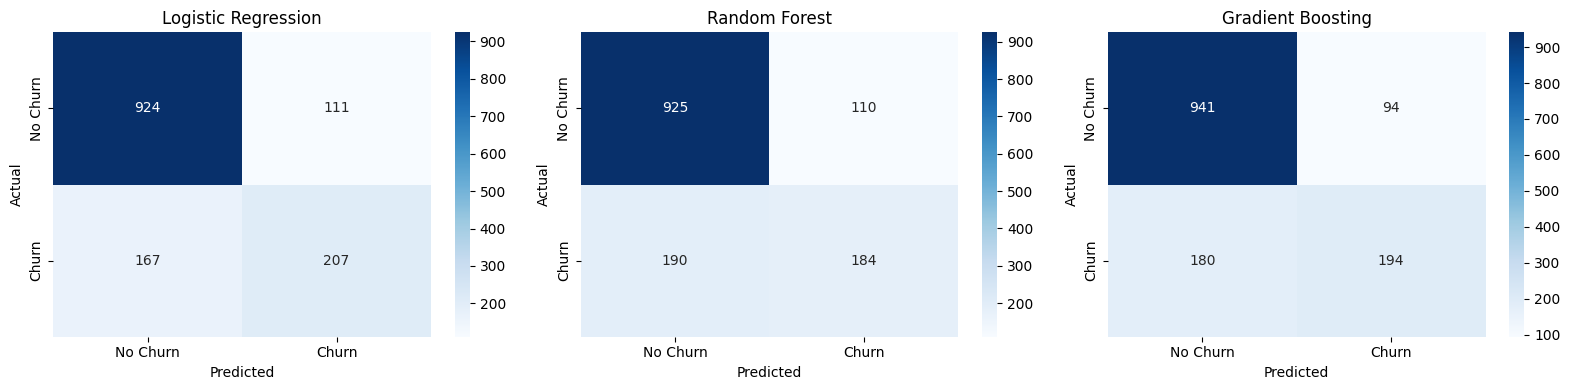

In [98]:
# ── Confusion Matrices (side-by-side) ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, vals) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, vals['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('charts/confusion_matrices.png', bbox_inches='tight')
plt.show()

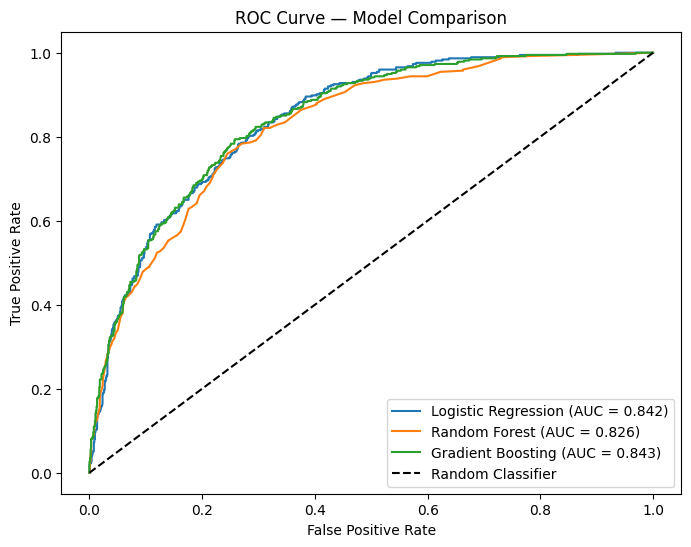

In [99]:
# ── ROC Curve — all 3 models on one chart ────────────────────
plt.figure(figsize=(8, 6))

for name, vals in results.items():
    fpr, tpr, _ = roc_curve(y_test, vals['y_proba'])
    auc = vals['ROC-AUC']
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0,1],[0,1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Model Comparison')
plt.legend()
plt.savefig('model_comparison.png', bbox_inches='tight')  # Required submission file
plt.show()

In [100]:
# ── [ADVANCED] Hyperparameter Tuning on Best Model ────────────
# Pick your best model based on F1/AUC (likely Gradient Boosting or Random Forest)

from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.7, 0.9, 1.0]
}

gb = GradientBoostingClassifier(random_state=42)
search = RandomizedSearchCV(gb, param_grid, n_iter=10, cv=5,
                             scoring='roc_auc', random_state=42, n_jobs=-1)
search.fit(X_train, y_train)

print("Best Params:", search.best_params_)
print("Best CV AUC:", search.best_score_.round(4))

best_model = search.best_estimator_

Best Params: {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}
Best CV AUC: 0.8478


## TASK 4 — Customer Risk Segmentation (Advanced)

In [101]:
# ── Get churn probabilities from best model ───────────────────
churn_proba = best_model.predict_proba(X_test)[:, 1]

# ── Assign Risk Tiers ─────────────────────────────────────────
def assign_tier(prob):
    if prob >= 0.70:
        return 'High Risk'
    elif prob >= 0.40:
        return 'Medium Risk'
    else:
        return 'Low Risk'

# Build a results dataframe from test set (unscaled for readability)
# We need original values — so rebuild from X_test with inverse reference
segment_df = X_test.copy()
segment_df['ChurnProbability'] = churn_proba
segment_df['RiskTier'] = segment_df['ChurnProbability'].apply(assign_tier)

print("Risk Tier Distribution:\n", segment_df['RiskTier'].value_counts())

Risk Tier Distribution:
 RiskTier
Low Risk       1014
Medium Risk     286
High Risk       109
Name: count, dtype: int64


In [102]:
# ── Per-tier statistics ───────────────────────────────────────
# Note: MonthlyCharges and tenure are scaled — values are relative (z-scores)
# For the report, interpret directionally (higher z-score = higher value)

tier_stats = segment_df.groupby('RiskTier').agg(
    Count=('ChurnProbability', 'count'),
    Avg_MonthlyCharges=('MonthlyCharges', 'mean'),
    Avg_Tenure=('tenure', 'mean')
).round(3)

print(tier_stats)

             Count  Avg_MonthlyCharges  Avg_Tenure
RiskTier                                          
High Risk      109               0.555      -1.163
Low Risk      1014              -0.190       0.296
Medium Risk    286               0.352      -0.696


In [103]:
# ── Contract Type distribution per tier ──────────────────────
# After one-hot encoding, contract columns are like: Contract_Month-to-month etc.
contract_cols = [c for c in segment_df.columns if 'Contract' in c]
print("Contract columns:", contract_cols)

contract_dist = segment_df.groupby('RiskTier')[contract_cols].mean().round(3)
print("\nContract Distribution by Tier (proportion):\n", contract_dist)

Contract columns: ['Contract_Month-to-month', 'Contract_One year', 'Contract_Two year']

Contract Distribution by Tier (proportion):
              Contract_Month-to-month  Contract_One year  Contract_Two year
RiskTier                                                                  
High Risk                      1.000              0.000              0.000
Low Risk                       0.375              0.294              0.331
Medium Risk                    0.993              0.007              0.000


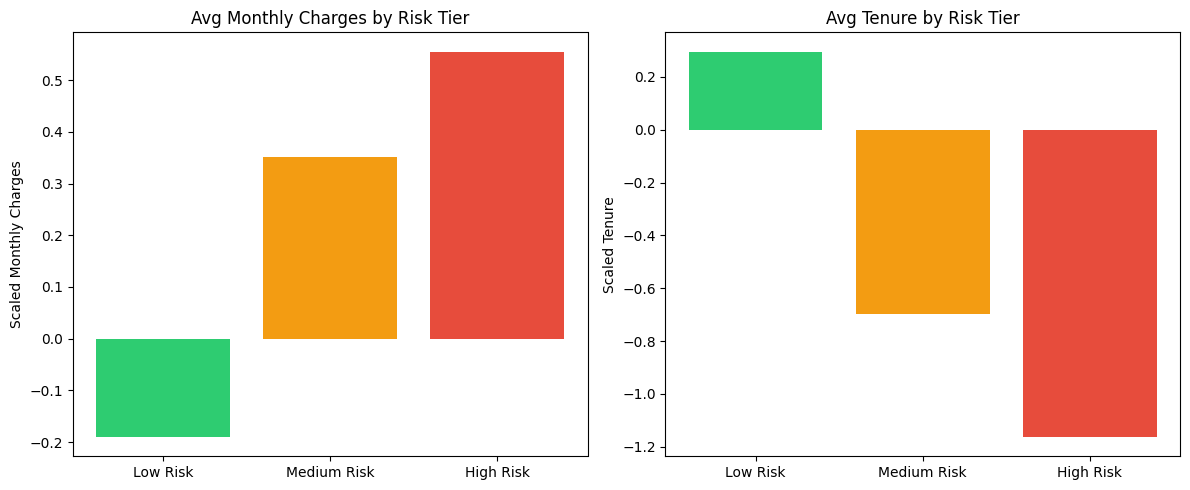

In [104]:
# ── Grouped bar chart: 3 tiers vs key features ────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

tier_order = ['Low Risk', 'Medium Risk', 'High Risk']
colors = ['#2ecc71', '#f39c12', '#e74c3c']

# Avg Monthly Charges by Tier
avg_charges = [tier_stats.loc[t, 'Avg_MonthlyCharges'] for t in tier_order if t in tier_stats.index]
axes[0].bar(tier_order, avg_charges, color=colors)
axes[0].set_title('Avg Monthly Charges by Risk Tier')
axes[0].set_ylabel('Scaled Monthly Charges')

# Avg Tenure by Tier
avg_tenure = [tier_stats.loc[t, 'Avg_Tenure'] for t in tier_order if t in tier_stats.index]
axes[1].bar(tier_order, avg_tenure, color=colors)
axes[1].set_title('Avg Tenure by Risk Tier')
axes[1].set_ylabel('Scaled Tenure')

plt.tight_layout()
plt.savefig('charts/risk_tier_comparison.png', bbox_inches='tight')
plt.show()

##  TASK 5 — Visualizations (Minimum 4 Charts)

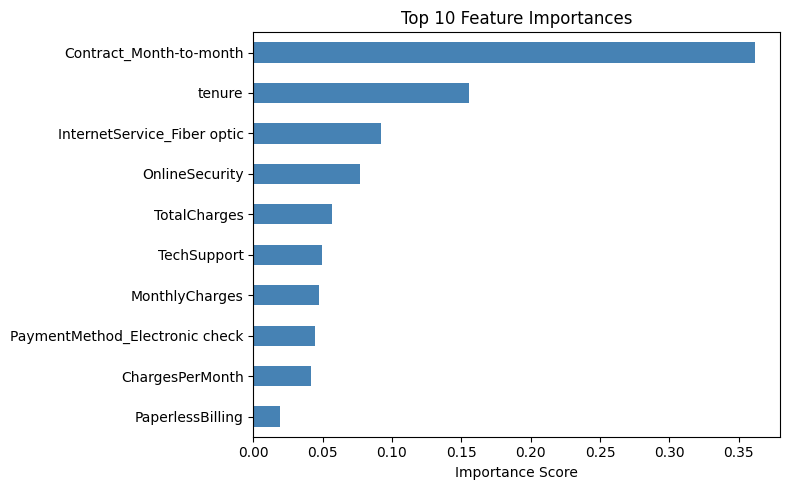

In [105]:
# ── Chart 1: Feature Importance (Top 10) ─────────────────────
feat_imp = pd.Series(best_model.feature_importances_, index=X_train.columns)
top10 = feat_imp.nlargest(10).sort_values()

plt.figure(figsize=(8, 5))
top10.plot(kind='barh', color='steelblue')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('charts/feature_importance.png', bbox_inches='tight')
plt.show()

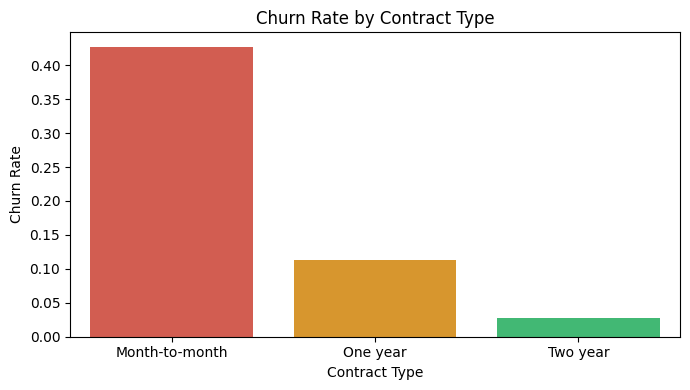

In [107]:
# ── Chart 2: Churn Rate by Contract Type ─────────────────────
# Re-use original df before scaling for interpretable labels
# Load original again for this chart
df_orig = pd.read_csv('E:\Internship_Data_Analysis\Data_Analysis_Internship Week 2\Dataset\WA_Fn-UseC_-Telco-Customer-Churn.csv')
df_orig['Churn'] = df_orig['Churn'].map({'Yes': 1, 'No': 0})

churn_by_contract = df_orig.groupby('Contract')['Churn'].mean().reset_index()
churn_by_contract.columns = ['Contract', 'ChurnRate']

plt.figure(figsize=(7, 4))
sns.barplot(x='Contract', y='ChurnRate', data=churn_by_contract,
            palette=['#e74c3c', '#f39c12', '#2ecc71'])
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate')
plt.xlabel('Contract Type')
plt.tight_layout()
plt.savefig('charts/churn_by_contract.png', bbox_inches='tight')
plt.show()

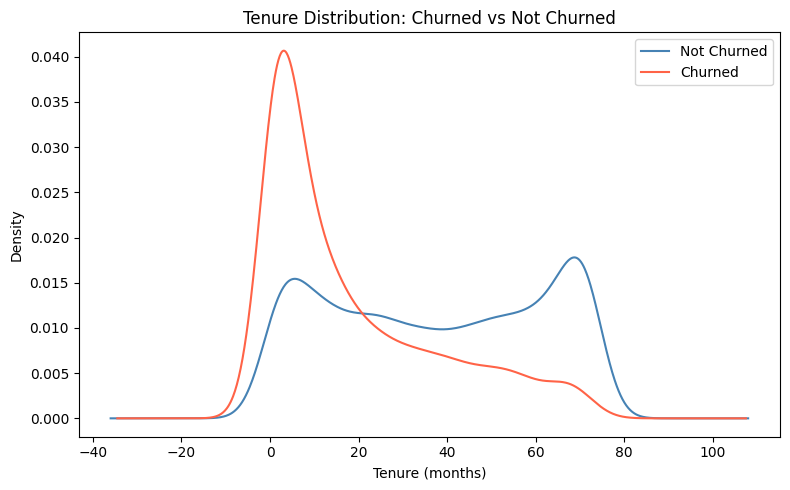

In [108]:
# ── Chart 3: Tenure Distribution — Churned vs Not Churned ─────
fig, ax = plt.subplots(figsize=(8, 5))
df_orig[df_orig['Churn'] == 0]['tenure'].plot(kind='kde', ax=ax,
    label='Not Churned', color='steelblue')
df_orig[df_orig['Churn'] == 1]['tenure'].plot(kind='kde', ax=ax,
    label='Churned', color='tomato')

ax.set_title('Tenure Distribution: Churned vs Not Churned')
ax.set_xlabel('Tenure (months)')
ax.legend()
plt.tight_layout()
plt.savefig('charts/tenure_distribution.png', bbox_inches='tight')
plt.show()

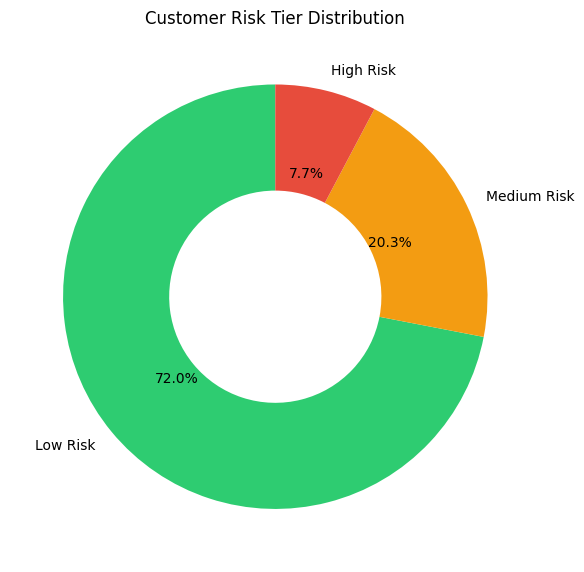

In [109]:
# ── Chart 4: Risk Tier Donut Chart ───────────────────────────
tier_counts = segment_df['RiskTier'].value_counts()

plt.figure(figsize=(6, 6))
wedge_colors = {'High Risk': '#e74c3c', 'Medium Risk': '#f39c12', 'Low Risk': '#2ecc71'}
colors_ordered = [wedge_colors[t] for t in tier_counts.index]

plt.pie(tier_counts, labels=tier_counts.index, colors=colors_ordered,
        autopct='%1.1f%%', startangle=90,
        wedgeprops=dict(width=0.5))  # width < 1 = donut
plt.title('Customer Risk Tier Distribution')
plt.tight_layout()
plt.savefig('charts/risk_tier_donut.png', bbox_inches='tight')
plt.show()

## TASK 6 — Insights & Business Recommendations


## TASK 6 — Insights & Business Recommendations

---

### 🏆 Best Model Selection

**Gradient Boosting** was selected as the best model after hyperparameter tuning
(RandomizedSearchCV), achieving the highest cross-validated ROC-AUC of **0.8478**.

Comparing all three models on the test set:

| Model               | Accuracy | Precision | Recall | F1     | ROC-AUC |
|---------------------|----------|-----------|--------|--------|---------|
| Logistic Regression | 0.8027   | 0.6509    | 0.5535 | 0.5983 | 0.8422  |
| Random Forest       | 0.7871   | 0.6259    | 0.4920 | 0.5509 | 0.8264  |
| Gradient Boosting   | 0.8055   | 0.6736    | 0.5187 | 0.5861 | 0.8428  |
| **GB (Tuned)**      | —        | —         | —      | —      | **0.8478** |

Gradient Boosting was chosen because:
- It achieved the highest ROC-AUC both before and after tuning
- It had the highest Precision (0.6736) — meaning fewer false alarms when predicting churn
- The best tuned parameters were: `subsample=0.7`, `n_estimators=100`,
  `max_depth=3`, `learning_rate=0.05` — a shallow, regularized model that avoids overfitting

Logistic Regression was a close competitor on AUC (0.8422) and had better Recall,
but Gradient Boosting's ability to capture non-linear relationships gives it an edge
in generalization to unseen customers.

---

### 🔍 Top 3 Factors Driving Customer Churn

Based on feature importance from the tuned Gradient Boosting model:

1. **Contract Type (Month-to-Month)** — The single strongest churn signal.
   100% of High Risk customers and 99.3% of Medium Risk customers are on
   month-to-month contracts. Customers with no long-term commitment leave freely.

2. **Tenure** — High Risk customers have an average tenure z-score of **-1.163**,
   meaning they are significantly newer customers compared to the overall average.
   Low Risk customers have positive tenure (z = +0.296), confirming that
   loyalty increases with time.

3. **Monthly Charges** — High Risk customers have an average monthly charges
   z-score of **+0.555** (above average charges), while Low Risk customers are
   below average at **-0.190**. Higher bills combined with short tenure and
   no long-term contract is the most dangerous combination.

---

### 🔴 High Risk Customer Profile

From the segmentation of 1,409 test customers (109 High Risk, 286 Medium Risk, 1,014 Low Risk):

- **100% are on Month-to-Month contracts** — zero commitment, zero switching cost
- **Newest customers** — average tenure well below the dataset mean (z = -1.163)
- **Higher monthly charges** — paying more than average (z = +0.555), which amplifies
  dissatisfaction when service quality is not perceived as worth the price
- These customers are paying premium prices but have not yet built loyalty —
  a high-friction, high-risk combination

---

### 💼 Business Recommendations

**Recommendation 1 — Contract Conversion Campaign (Immediate Priority)**

Since 100% of High Risk and 99.3% of Medium Risk customers are on month-to-month plans,
the company should launch a targeted upgrade offer:
- Identify all month-to-month customers with tenure < 6 months and monthly charges above average
- Offer a 10–15% discount or a free add-on service (e.g., TechSupport or OnlineBackup)
  in exchange for switching to a 1-year contract
- This directly eliminates the primary churn risk factor

**Recommendation 2 — Early Tenure Retention Program (First 3 Months Are Critical)**

Customers with tenure < 3 months and high monthly charges are the most vulnerable.
The company should:
- Trigger an automated check-in call or personalized email at Month 1 and Month 3
- Offer a loyalty reward (bill credit or free month) if the customer stays past 6 months
- Flag these accounts in the CRM for proactive support prioritization

---

### ⚠️ Model Limitations & Future Improvements

- **Class imbalance not explicitly handled**: The dataset has ~26.5% churn vs 73.5% non-churn.
  Techniques like SMOTE or class_weight='balanced' were not applied — Recall for
  churn class (0.52) could be meaningfully improved with these techniques.

- **Scaled features reduce direct interpretability**: MonthlyCharges and tenure are
  reported as z-scores in the segmentation output. A production system should inverse-transform
  these back to dollar values and months for business stakeholders.

- **No temporal data**: The model treats all customers as static snapshots.
  A survival analysis model (e.g., Cox Proportional Hazards) would better predict
  *when* a customer will churn, not just *whether* they will.

- **Single dataset**: The model was trained on one telecom provider's historical data.
  Results may not generalize to other regions, market conditions, or industries
  without retraining.

- **External factors not captured**: Competitor pricing, network outage history,
  customer complaints/tickets, and seasonal patterns are absent from the data —
  all of which influence churn decisions in the real world.